In [1]:
import tensorflow as tf

print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

2026-03-27 18:06:45.813456: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774634805.837489     982 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774634805.845135     982 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774634805.867246     982 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774634805.867269     982 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774634805.867272     982 computation_placer.cc:177] computation placer alr

Num GPUs Available: 1


In [2]:
import tensorflow as tf
import numpy as np
import h5py
import matplotlib.pyplot as plt

print("GPU:", tf.config.list_physical_devices('GPU'))

GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
from tensorflow.keras import mixed_precision

mixed_precision.set_global_policy('mixed_float16')

In [4]:
import h5py

base_path = "/kaggle/input/datasets/andrewmvd/metastatic-tissue-classification-patchcamelyon"


train_img = h5py.File(f"{base_path}/pcam/training_split.h5", "r")
val_img = h5py.File(f"{base_path}/pcam/validation_split.h5", "r")
test_img = h5py.File(f"{base_path}/pcam/test_split.h5", "r")


train_lbl = h5py.File(f"{base_path}/Labels/Labels/camelyonpatch_level_2_split_train_y.h5", "r")
val_lbl = h5py.File(f"{base_path}/Labels/Labels/camelyonpatch_level_2_split_valid_y.h5", "r")
test_lbl = h5py.File(f"{base_path}/Labels/Labels/camelyonpatch_level_2_split_test_y.h5", "r")

In [5]:
x_train = train_img['x']
y_train = train_lbl['y']

x_val = val_img['x']
y_val = val_lbl['y']

x_test = test_img['x']
y_test = test_lbl['y']

In [6]:
print(x_train.shape, y_train.shape)

(262144, 96, 96, 3) (262144, 1, 1, 1)


In [7]:
import numpy as np

y_train = np.squeeze(y_train)
y_val = np.squeeze(y_val)
y_test = np.squeeze(y_test)

print(y_train.shape)

(262144,)


In [8]:
IMG_SIZE = 224

def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

In [9]:
y_train = np.squeeze(y_train).astype("float32")
y_val = np.squeeze(y_val).astype("float32")
y_test = np.squeeze(y_test).astype("float32")

In [10]:
TRAIN_SAMPLES = 70000
VAL_SAMPLES = 10000
TEST_SAMPLES = 10000

In [11]:
ds_train = tf.data.Dataset.from_tensor_slices((x_train[:TRAIN_SAMPLES], y_train[:TRAIN_SAMPLES]))
ds_val = tf.data.Dataset.from_tensor_slices((x_val[:VAL_SAMPLES], y_val[:VAL_SAMPLES]))
ds_test = tf.data.Dataset.from_tensor_slices((x_test[:TEST_SAMPLES], y_test[:TEST_SAMPLES]))

I0000 00:00:1774634835.476261     982 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [12]:
IMG_SIZE = 224
BATCH_SIZE = 32

def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

ds_train = ds_train.map(preprocess).shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
ds_val = ds_val.map(preprocess).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
ds_test = ds_test.map(preprocess).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam

base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)


for layer in base_model.layers[:-20]:
    layer.trainable = False
for layer in base_model.layers[-20:]:
    layer.trainable = True

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
output = layers.Dense(1, activation='sigmoid')(x)

model_b0 = models.Model(inputs=base_model.input, outputs=output)

model_b0.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [14]:
from tensorflow.keras.callbacks import EarlyStopping

early = EarlyStopping(patience=2, restore_best_weights=True)

history_b0 = model_b0.fit(
    ds_train,
    validation_data=ds_val,
    epochs=8,
    callbacks=[early]
)

Epoch 1/8


I0000 00:00:1774634865.671632    1047 service.cc:152] XLA service 0x7b1af4001660 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774634865.671669    1047 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1774634868.353715    1047 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1774634896.201191    1047 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2188/2188 ━━━━━━━━━━━━━━━━━━━━ 188s 62ms/step - accuracy: 0.5393 - loss: 0.6885 - val_accuracy: 0.5425 - val_loss: 0.6883
Epoch 2/8
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 72s 33ms/step - accuracy: 0.5884 - loss: 0.6651 - val_accuracy: 0.5852 - val_loss: 0.6588
Epoch 3/8
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 74s 33ms/step - accuracy: 0.6292 - loss: 0.6439 - val_accuracy: 0.7088 - val_loss: 0.6203
Epoch 4/8
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 72s 33ms/step - accuracy: 0.6572 - loss: 0.6259 - val_accuracy: 0.7162 - val_loss: 0.5969
Epoch 5/8
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 70s 32ms/step - accuracy: 0.6711 - loss: 0.6105 - val_accuracy: 0.7252 - val_loss: 0.5743
Epoch 6/8
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 71s 32ms/step - accuracy: 0.6767 - loss: 0.6018 - val_accuracy: 0.6939 - val_loss: 0.6001
Epoch 7/8
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 70s 32ms/step - accuracy: 0.6812 - loss: 0.5951 - val_accuracy: 0.7243 - val_loss: 0.5719
Epoch 8/8
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 71s 32ms/step - accuracy: 0.6860 - loss: 0.5911 - v

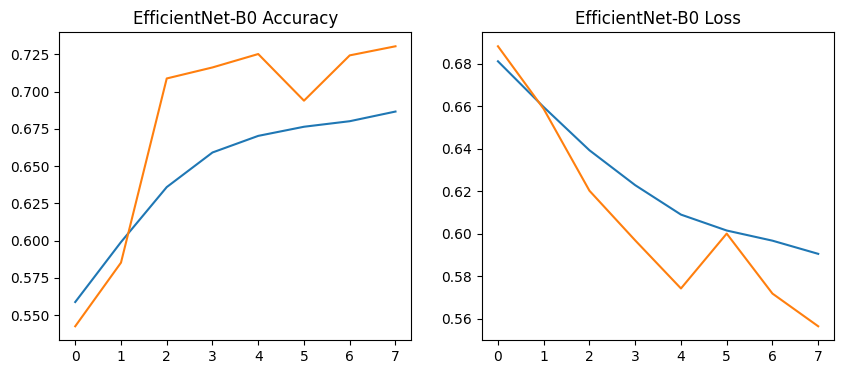

In [15]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history_b0.history['accuracy'])
plt.plot(history_b0.history['val_accuracy'])
plt.title("EfficientNet-B0 Accuracy")

plt.subplot(1,2,2)
plt.plot(history_b0.history['loss'])
plt.plot(history_b0.history['val_loss'])
plt.title("EfficientNet-B0 Loss")

plt.show()

In [16]:
b0_results = {
    "model": "EfficientNet-B0",
    "val_accuracy": max(history_b0.history['val_accuracy'])
}

In [17]:
y_pred_prob = model_b0.predict(ds_test)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

313/313 ━━━━━━━━━━━━━━━━━━━━ 32s 61ms/step


In [18]:
y_true = y_test[:10000]

In [19]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

         0.0       0.81      0.65      0.72      5010
         1.0       0.71      0.84      0.77      4990

    accuracy                           0.75     10000
   macro avg       0.76      0.75      0.74     10000
weighted avg       0.76      0.75      0.74     10000



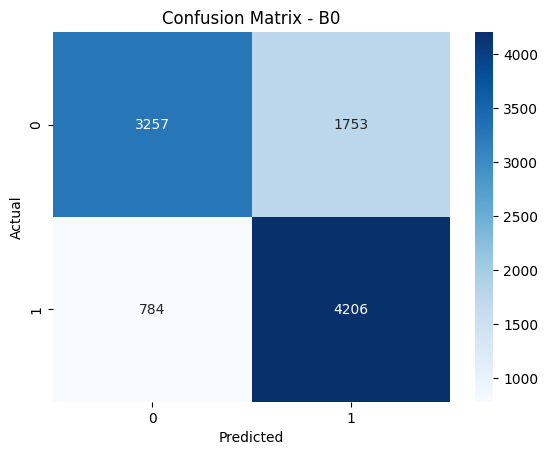

In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - B0")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

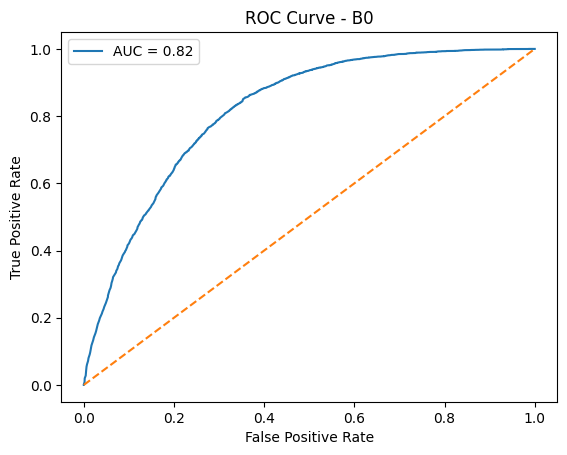

In [21]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - B0")
plt.legend()
plt.show()

In [22]:
from tensorflow.keras.applications import EfficientNetB4
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam

base_model = EfficientNetB4(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)


for layer in base_model.layers[:-30]:
    layer.trainable = False
for layer in base_model.layers[-30:]:
    layer.trainable = True

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)   
x = layers.Dropout(0.4)(x)
output = layers.Dense(1, activation='sigmoid')(x)

model_b4 = models.Model(inputs=base_model.input, outputs=output)

model_b4.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [23]:
model_b4.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_1     │ (None, 224, 224,  │          7 │ rescaling_2[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_3         │ (None, 224, 224,  │          0 │ normalization_1[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_3[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │      1,296 │ stem_conv_pad[0]… │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        192 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        432 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        192 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 48)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 48)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 12)  │        588 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 48)  │        624 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 48)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │      1,152 │ block1a_se_excit

 Total params: 18,133,088 (69.17 MB)

 Trainable params: 5,291,765 (20.19 MB)

 Non-trainable params: 12,841,323 (48.99 MB)

In [24]:
from tensorflow.keras.callbacks import EarlyStopping

early = EarlyStopping(patience=2, restore_best_weights=True)

history_b4 = model_b4.fit(
    ds_train,
    validation_data=ds_val,
    epochs=8,
    callbacks=[early]
)

Epoch 1/8
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 340s 117ms/step - accuracy: 0.5763 - loss: 0.6692 - val_accuracy: 0.6339 - val_loss: 0.6493
Epoch 2/8
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 149s 68ms/step - accuracy: 0.6201 - loss: 0.6436 - val_accuracy: 0.6791 - val_loss: 0.6307
Epoch 3/8
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 149s 68ms/step - accuracy: 0.6331 - loss: 0.6355 - val_accuracy: 0.6801 - val_loss: 0.6194
Epoch 4/8
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 149s 68ms/step - accuracy: 0.6433 - loss: 0.6292 - val_accuracy: 0.6903 - val_loss: 0.6051
Epoch 5/8
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 149s 68ms/step - accuracy: 0.6521 - loss: 0.6214 - val_accuracy: 0.7190 - val_loss: 0.5723
Epoch 6/8
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 148s 68ms/step - accuracy: 0.6611 - loss: 0.6118 - val_accuracy: 0.7336 - val_loss: 0.5524
Epoch 7/8
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 149s 68ms/step - accuracy: 0.6732 - loss: 0.6027 - val_accuracy: 0.7381 - val_loss: 0.5391
Epoch 8/8
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 149s 68ms/step - accuracy: 0.6864 

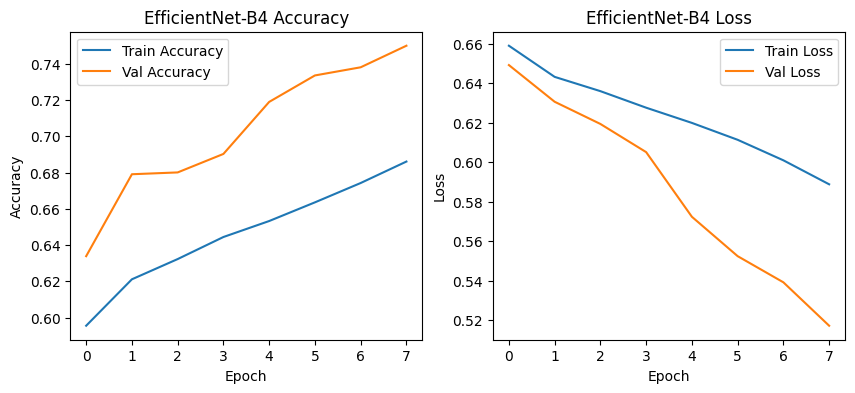

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))


plt.subplot(1,2,1)
plt.plot(history_b4.history['accuracy'], label='Train Accuracy')
plt.plot(history_b4.history['val_accuracy'], label='Val Accuracy')
plt.title("EfficientNet-B4 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()


plt.subplot(1,2,2)
plt.plot(history_b4.history['loss'], label='Train Loss')
plt.plot(history_b4.history['val_loss'], label='Val Loss')
plt.title("EfficientNet-B4 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [26]:
y_pred_prob_b4 = model_b4.predict(ds_test)
y_pred_b4 = (y_pred_prob_b4 > 0.5).astype(int).flatten()

313/313 ━━━━━━━━━━━━━━━━━━━━ 64s 126ms/step


In [27]:
from sklearn.metrics import classification_report

print(classification_report(y_test[:10000], y_pred_b4))

              precision    recall  f1-score   support

         0.0       0.84      0.66      0.74      5010
         1.0       0.72      0.87      0.79      4990

    accuracy                           0.77     10000
   macro avg       0.78      0.77      0.77     10000
weighted avg       0.78      0.77      0.77     10000



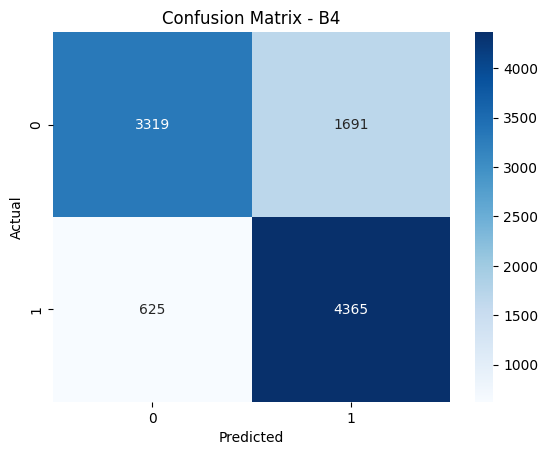

In [28]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test[:10000], y_pred_b4)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - B4")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

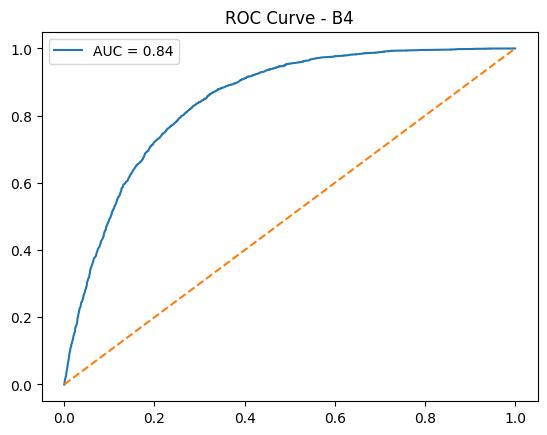

In [29]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test[:10000], y_pred_prob_b4)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.title("ROC Curve - B4")
plt.legend()
plt.show()

In [30]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam

base_model = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)


for layer in base_model.layers[:-30]:
    layer.trainable = False
for layer in base_model.layers[-30:]:
    layer.trainable = True

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
output = layers.Dense(1, activation='sigmoid')(x)

model_dn = models.Model(inputs=base_model.input, outputs=output)

model_dn.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [31]:
model_dn.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 7,168,833 (27.35 MB)

 Trainable params: 772,737 (2.95 MB)

 Non-trainable params: 6,396,096 (24.40 MB)

In [32]:
from tensorflow.keras.callbacks import EarlyStopping

early = EarlyStopping(patience=2, restore_best_weights=True)

history_dn = model_dn.fit(
    ds_train,
    validation_data=ds_val,
    epochs=8,
    callbacks=[early]
)

Epoch 1/8
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 217s 80ms/step - accuracy: 0.7164 - loss: 0.5472 - val_accuracy: 0.8318 - val_loss: 0.3651
Epoch 2/8
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 130s 59ms/step - accuracy: 0.8525 - loss: 0.3379 - val_accuracy: 0.8404 - val_loss: 0.3477
Epoch 3/8
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 131s 60ms/step - accuracy: 0.8765 - loss: 0.2897 - val_accuracy: 0.8476 - val_loss: 0.3394
Epoch 4/8
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 131s 60ms/step - accuracy: 0.8928 - loss: 0.2640 - val_accuracy: 0.8536 - val_loss: 0.3315
Epoch 5/8
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 131s 60ms/step - accuracy: 0.9039 - loss: 0.2401 - val_accuracy: 0.8533 - val_loss: 0.3335
Epoch 6/8
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 132s 60ms/step - accuracy: 0.9110 - loss: 0.2223 - val_accuracy: 0.8578 - val_loss: 0.3288
Epoch 7/8
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 131s 60ms/step - accuracy: 0.9170 - loss: 0.2112 - val_accuracy: 0.8543 - val_loss: 0.3360
Epoch 8/8
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 131s 60ms/step - accuracy: 0.9245 -

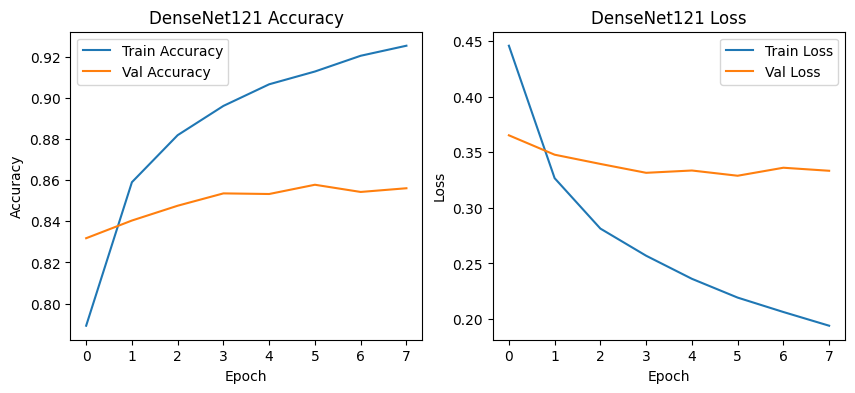

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))


plt.subplot(1,2,1)
plt.plot(history_dn.history['accuracy'], label='Train Accuracy')
plt.plot(history_dn.history['val_accuracy'], label='Val Accuracy')
plt.title("DenseNet121 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_dn.history['loss'], label='Train Loss')
plt.plot(history_dn.history['val_loss'], label='Val Loss')
plt.title("DenseNet121 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [36]:
y_pred_prob_dn = model_dn.predict(ds_test)
y_pred_dn = (y_pred_prob_dn > 0.5).astype(int).flatten()

313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 44ms/step


In [37]:
from sklearn.metrics import classification_report
print(classification_report(y_test[:10000], y_pred_dn))

              precision    recall  f1-score   support

         0.0       0.79      0.94      0.86      5010
         1.0       0.92      0.75      0.83      4990

    accuracy                           0.84     10000
   macro avg       0.85      0.84      0.84     10000
weighted avg       0.85      0.84      0.84     10000



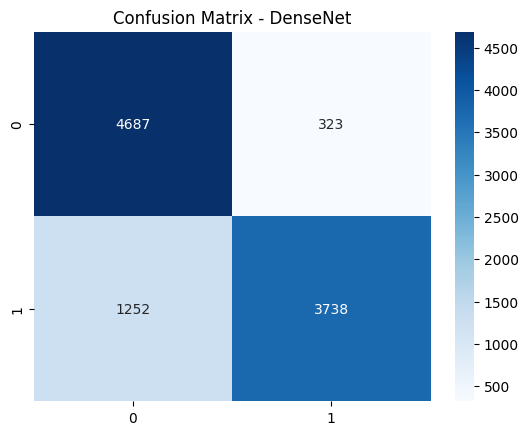

In [38]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test[:10000], y_pred_dn)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - DenseNet")
plt.show()

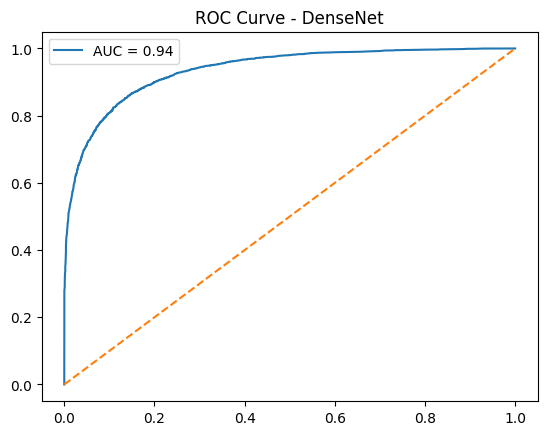

In [39]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test[:10000], y_pred_prob_dn)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve - DenseNet")
plt.legend()
plt.show()

In [42]:
import matplotlib.pyplot as plt


sample_images = x_test[:10]
sample_labels = y_test[:10]

In [43]:

sample_images_resized = tf.image.resize(sample_images, (224,224)) / 255.0


pred_b0 = (model_b0.predict(sample_images_resized) > 0.5).astype(int)
pred_b4 = (model_b4.predict(sample_images_resized) > 0.5).astype(int)
pred_dn = (model_dn.predict(sample_images_resized) > 0.5).astype(int)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


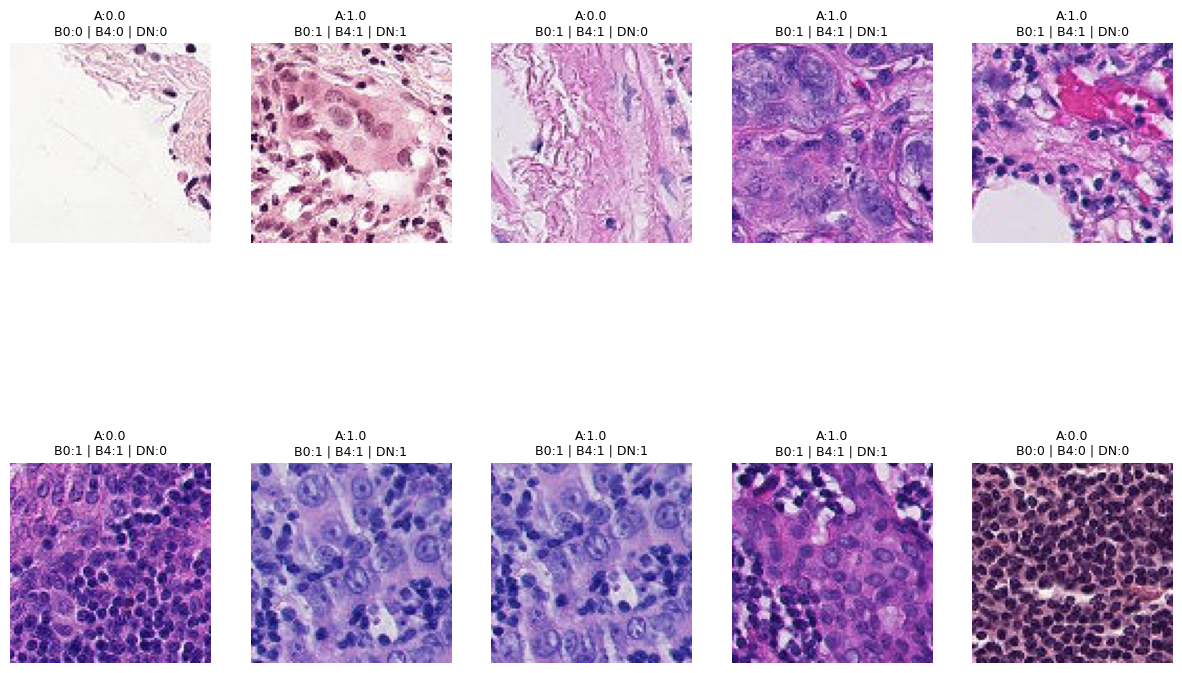

In [44]:
plt.figure(figsize=(15,10))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(sample_images[i])
    plt.axis('off')
    
    plt.title(
        f"A:{sample_labels[i]}\nB0:{pred_b0[i][0]} | B4:{pred_b4[i][0]} | DN:{pred_dn[i][0]}",
        fontsize=9
    )

plt.show()

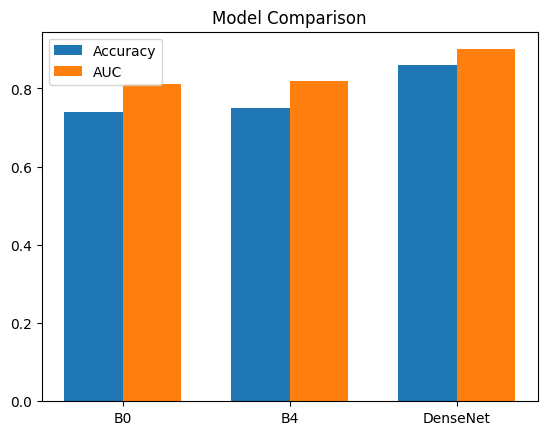

In [46]:
import numpy as np

x = np.arange(len(models))
width = 0.35

plt.bar(x - width/2, accuracy, width, label='Accuracy')
plt.bar(x + width/2, auc, width, label='AUC')

plt.xticks(x, models)
plt.legend()
plt.title("Model Comparison")

plt.show()

In [49]:
for i in range(10):
    if y_true[i] != pred_b0[i] and y_true[i] == pred_dn[i]:
        print("DenseNet corrected B0 mistake at index:", i)

DenseNet corrected B0 mistake at index: 2
DenseNet corrected B0 mistake at index: 5


In [50]:
for i in range(10):
    if y_true[i] != pred_b4[i] and y_true[i] == pred_dn[i]:
        print("DenseNet corrected B4 mistake at index:", i)

DenseNet corrected B4 mistake at index: 2
DenseNet corrected B4 mistake at index: 5


In [51]:
for i in range(10):
    if y_true[i] != pred_b0[i] and y_true[i] == pred_b4[i]:
        print("B4 corrected B0 mistake at index:", i)